<a href="https://colab.research.google.com/github/ramakant-BIM/JSW-Projects/blob/main/Package_score.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Image Extraction + OpenCV Design Analytics

In [ ]:
# =====================================================
# SEGMENT 1
# PACKAGE VISUAL ANALYTICS ENGINE
# =====================================================

!pip install opencv-python pandas numpy openpyxl tqdm

import os
import cv2
import zipfile
import numpy as np
import pandas as pd
from tqdm import tqdm

# =====================================================
# UPLOAD ZIP
# =====================================================

from google.colab import files

uploaded = files.upload()

zip_name = list(uploaded.keys())[0]

extract_folder = "/content/package_images"

with zipfile.ZipFile(zip_name,'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print("Images Extracted")

# =====================================================
# IMAGE PATHS
# =====================================================

image_paths = []

for root, dirs, files_ in os.walk(extract_folder):
    for f in files_:
        if f.lower().endswith(('.jpg','.jpeg','.png','.webp','.bmp')):
            image_paths.append(os.path.join(root,f))

print("Total Images:",len(image_paths))

# =====================================================
# FEATURE EXTRACTION
# =====================================================

visual_results = []

for img_path in tqdm(image_paths):

    img = cv2.imread(img_path)

    if img is None:
        continue

    h,w,_ = img.shape

    img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    hsv = cv2.cvtColor(img,cv2.COLOR_BGR2HSV)

    brightness = np.mean(hsv[:,:,2])

    saturation = np.mean(hsv[:,:,1])

    contrast = np.std(cv2.cvtColor(img,cv2.COLOR_BGR2GRAY))

    reshaped = img_rgb.reshape((-1,3))

    unique_colors = len(np.unique(reshaped,axis=0))

    color_diversity = unique_colors/len(reshaped)

    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

    white_pixels = np.sum(gray > 230)

    whitespace_ratio = white_pixels/(h*w)

    if h > w:
        structure = "Bucket/Cylindrical"
        structure_score = 8
    else:
        structure = "Rectangular"
        structure_score = 6

    visual_results.append([
        img_path,
        brightness,
        saturation,
        contrast,
        color_diversity,
        whitespace_ratio,
        structure,
        structure_score
    ])

visual_df = pd.DataFrame(
    visual_results,
    columns=[
        "Image",
        "Brightness",
        "Saturation",
        "Contrast",
        "Color_Diversity",
        "Whitespace",
        "Structure",
        "Structure_Score"
    ]
)

visual_df.head()

Saving Paint_packets.zip to Paint_packets.zip
Images Extracted
Total Images: 54


100%|██████████| 54/54 [00:38<00:00,  1.42it/s]


,Image,Brightness,Saturation,Contrast,Color_Diversity,Whitespace,Structure,Structure_Score
0,/content/package_images/Paint_packets/Screensh...,184.222788,104.711791,67.735661,0.176348,0.236951,Bucket/Cylindrical,8
1,/content/package_images/Paint_packets/Screensh...,141.994283,47.955844,80.992528,0.134127,0.155370,Bucket/Cylindrical,8
2,/content/package_images/Paint_packets/Screensh...,206.948976,85.136703,59.044953,0.227252,0.167716,Bucket/Cylindrical,8
3,/content/package_images/Paint_packets/Screensh...,157.715732,89.553801,63.401005,0.132579,0.033419,Bucket/Cylindrical,8
4,/content/package_images/Paint_packets/Screensh...,158.373134,19.117039,71.632867,0.063808,0.247291,Bucket/Cylindrical,8


The previous execution was interrupted during the file upload process. I will now proceed with extracting the `Paint_packets.zip` file, which appears to have been successfully uploaded, and then regenerate the subsequent data processing steps.

##OCR Communication Analysis

In [ ]:
# =====================================================
# SEGMENT 2
# OCR COMMUNICATION ENGINE
# =====================================================

!pip install easyocr

import easyocr
import pandas as pd
import numpy as np
from tqdm import tqdm

reader = easyocr.Reader(['en'])

ocr_results = []

benefit_keywords = [
    "washable",
    "anti",
    "weather",
    "durable",
    "coverage",
    "shine",
    "finish",
    "resistant",
    "waterproof",
    "luxury",
    "premium",
    "warranty",
    "technology",
    "smooth",
    "stain"
]

product_keywords = [
    "interior",
    "exterior",
    "emulsion",
    "primer",
    "putty",
    "paint"
]

for img_path in tqdm(image_paths):

    try:

        results = reader.readtext(img_path)

        texts = []

        total_text_area = 0

        img = cv2.imread(img_path)

        h,w,_ = img.shape

        image_area = h*w

        for item in results:

            bbox,text,conf = item

            texts.append(text)

            x1 = int(bbox[0][0])
            y1 = int(bbox[0][1])

            x2 = int(bbox[2][0])
            y2 = int(bbox[2][1])

            area = abs((x2-x1)*(y2-y1))

            total_text_area += area

        full_text = " ".join(texts).lower()

        benefit_count = sum(
            kw in full_text for kw in benefit_keywords
        )

        product_count = sum(
            kw in full_text for kw in product_keywords
        )

        text_density = total_text_area/image_area

        clarity_score = (
            benefit_count*2 +
            product_count*2 +
            (1-text_density)*5
        )

        ocr_results.append([
            img_path,
            len(texts),
            benefit_count,
            product_count,
            text_density,
            clarity_score,
            full_text
        ])

    except:
        continue

ocr_df = pd.DataFrame(
    ocr_results,
    columns=[
        "Image",
        "Text_Count",
        "Benefit_Count",
        "Product_Count",
        "Text_Density",
        "Clarity_Score",
        "Extracted_Text"
    ]
)

ocr_df.head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 24.3 MB/s eta 0:00:00


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

  0%|          | 0/54 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
  2%|▏         | 1/54 [00:10<09:34, 10.83s/it]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
  4%|▎         | 2/54 [00:21<09:16, 10.71s/it]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
  6%|▌         | 3/54 [00:28<07:51,  9.24s/it]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, 

,Image,Text_Count,Benefit_Count,Product_Count,Text_Density,Clarity_Score,Extracted_Text
0,/content/package_images/Paint_packets/Screensh...,22,2,3,0.314957,13.425216,eggshell interior valspar medallion paint prim...
1,/content/package_images/Paint_packets/Screensh...,16,0,1,0.313631,5.431847,"farrow& ball in paint and & bw"" fb craftsmen p..."
2,/content/package_images/Paint_packets/Screensh...,3,0,0,0.191006,4.044970,royale wall basecoat l
3,/content/package_images/Paint_packets/Screensh...,26,0,3,0.181538,10.092309,enco a c r y [ | c duracoat 2x tr u e c a r e ...
4,/content/package_images/Paint_packets/Screensh...,7,0,0,0.091590,4.542049,apex ultima wentlicarioor [ durtngn pu vears


The OCR analysis will now be re-executed to ensure `ocr_df` is correctly generated, as it depends on `image_paths` which was re-created in the previous step.

##Packaging Effectiveness Index (PEI)

In [ ]:
# =====================================================
# SEGMENT 3
# PACKAGING EFFECTIVENESS INDEX
# =====================================================

from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

final_df = visual_df.merge(
    ocr_df,
    on="Image",
    how="left"
)

final_df.fillna(0,inplace=True)

# =======================================
# NORMALIZATION
# =======================================

metrics = [
    "Brightness",
    "Saturation",
    "Contrast",
    "Color_Diversity",
    "Whitespace",
    "Structure_Score",
    "Clarity_Score"
]

scaler = MinMaxScaler()

final_df[metrics] = scaler.fit_transform(
    final_df[metrics]
)

# =======================================
# VISIBILITY SCORE
# =======================================

final_df["Visibility"] = (
    0.30*final_df["Brightness"] +
    0.30*final_df["Saturation"] +
    0.40*final_df["Contrast"]
)*10

# =======================================
# PREMIUM SCORE
# =======================================

final_df["Premium"] = (
    0.35*final_df["Whitespace"] +
    0.25*final_df["Contrast"] +
    0.25*final_df["Color_Diversity"] +
    0.15*final_df["Structure_Score"]
)*10

# =======================================
# MODERNITY SCORE
# =======================================

final_df["Modernity"] = (
    0.40*final_df["Whitespace"] +
    0.30*final_df["Color_Diversity"] +
    0.30*final_df["Contrast"]
)*10

# =======================================
# HIERARCHY SCORE
# =======================================

final_df["Hierarchy"] = (
    (1-final_df["Text_Density"])*10
)

# =======================================
# FINAL PEI
# =======================================

final_df["PEI"] = (

    0.20*final_df["Visibility"] +

    0.25*final_df["Premium"] +

    0.20*final_df["Clarity_Score"] +

    0.15*final_df["Hierarchy"] +

    0.10*final_df["Modernity"] +

    0.10*(final_df["Structure_Score"]*10)

)

# =======================================
# BRAND EXTRACTION
# =======================================

final_df["Brand"] = final_df["Image"].apply(
    lambda x: os.path.basename(x)
)

# =======================================
# RANKING
# =======================================

final_df = final_df.sort_values(
    "PEI",
    ascending=False
)

# =======================================
# SAVE EXCEL
# =======================================

output_file = "/content/Packaging_Benchmark.xlsx"

final_df.to_excel(
    output_file,
    index=False
)

print("Saved:",output_file)

final_df[
[
"Brand",
"Visibility",
"Premium",
"Clarity_Score",
"Hierarchy",
"Modernity",
"PEI"
]
].head(20)

Saved: /content/Packaging_Benchmark.xlsx


,Brand,Visibility,Premium,Clarity_Score,Hierarchy,Modernity,PEI
42,Screenshot 2026-06-18 161343.png,6.895266,7.714466,0.416481,7.638348,7.333660,6.270084
25,Screenshot 2026-06-18 160028.png,5.989997,6.614465,0.596387,8.665719,5.998492,5.870600
51,Screenshot 2026-06-18 160345.png,6.854232,5.784113,0.313197,8.752119,5.050276,5.697359
52,Screenshot 2026-06-18 160222.png,6.990394,5.300083,0.750984,8.985851,4.490634,5.670238
20,Screenshot 2026-06-18 162848.png,7.017880,6.101714,0.396016,7.066447,5.419864,5.610161
26,Screenshot 2026-06-18 161933.png,6.266537,5.704448,0.733307,8.491884,4.942593,5.594123
36,Screenshot 2026-06-18 162207.png,5.643826,5.969420,0.320982,8.969680,5.253501,5.556119
34,Screenshot 2026-06-18 160426.png,6.967594,5.142509,0.600006,8.766854,4.295521,5.543728
27,Screenshot 2026-06-18 162254.png,6.742362,5.284844,0.323815,9.048836,4.429836,5.534755
22,Screenshot 2026-06-10 141222.png,5.339693,6.067974,1.000000,7.944475,5.397080,5.516311


Now that `visual_df` and `ocr_df` are correctly generated, I will re-calculate the Packaging Effectiveness Index (PEI) to create `final_df`.

##EDA

Now, let's visualize the correlation between all PEI component scores using a heatmap, as you requested.

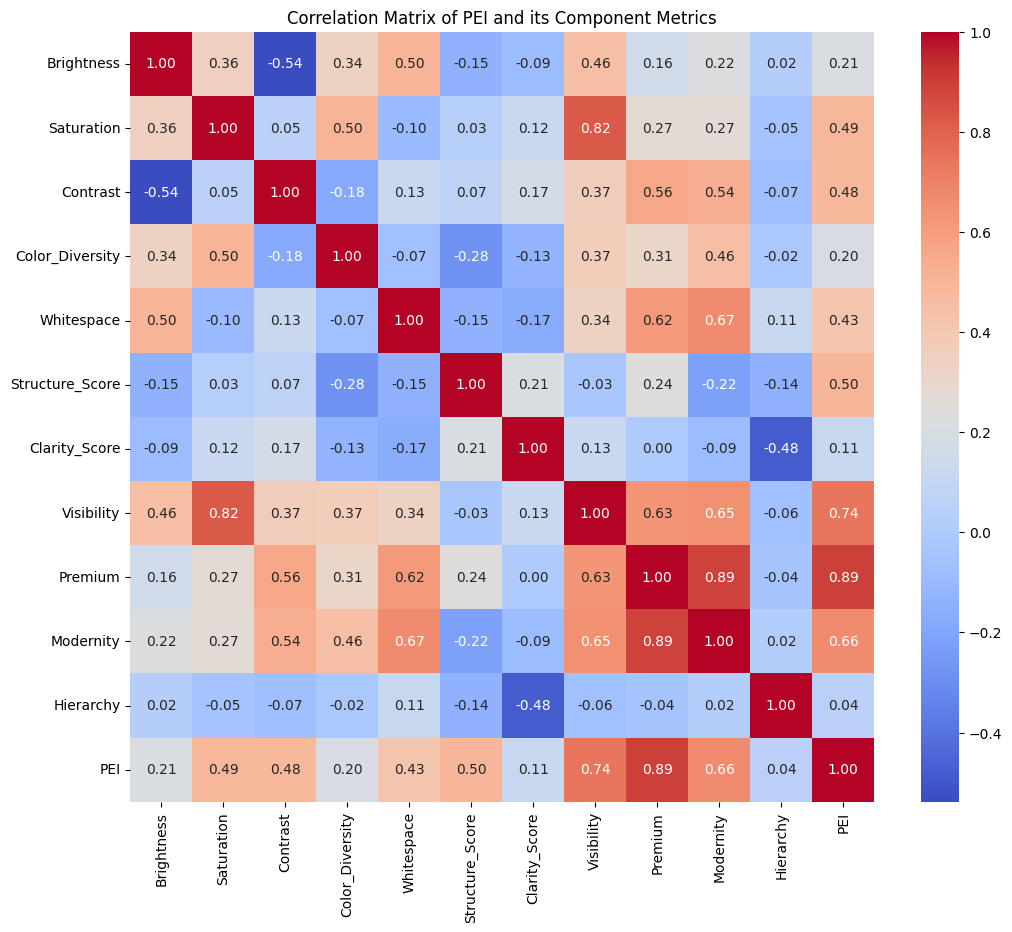

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics_for_correlation = [
    "Brightness",
    "Saturation",
    "Contrast",
    "Color_Diversity",
    "Whitespace",
    "Structure_Score",
    "Clarity_Score",
    "Visibility",
    "Premium",
    "Modernity",
    "Hierarchy",
    "PEI"
]

correlation_matrix = final_df[metrics_for_correlation].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of PEI and its Component Metrics')
plt.show()

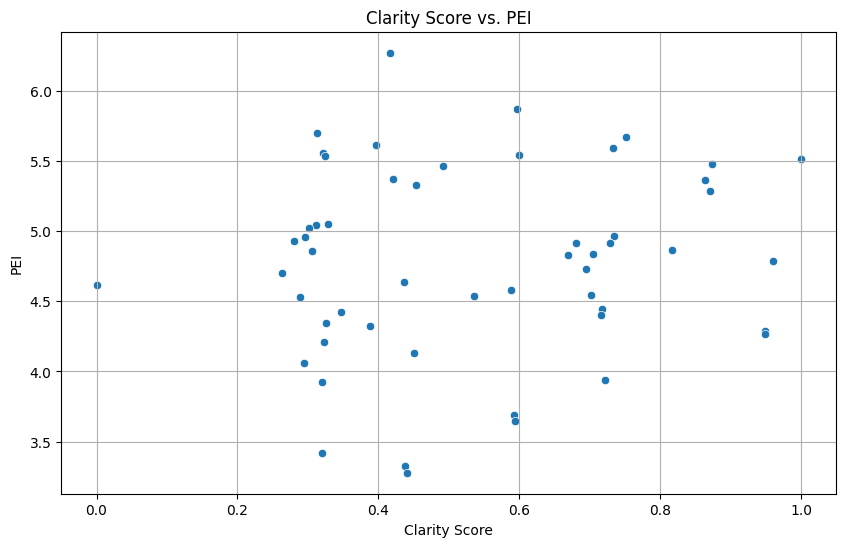

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Clarity_Score', y='PEI', data=final_df)
plt.title('Clarity Score vs. PEI')
plt.xlabel('Clarity Score')
plt.ylabel('PEI')
plt.grid(True)
plt.show()

In [ ]:
highest_pei_image = final_df.sort_values(by='PEI', ascending=False).iloc[0]['Image']
print(f'The image with the highest PEI score is: {highest_pei_image}')

The image with the highest PEI score is: /content/package_images/Paint_packets/Screenshot 2026-06-18 161343.png


In [ ]:
image_with_highest_pei_metrics = final_df[final_df['Image'] == highest_pei_image]
display(image_with_highest_pei_metrics)

,Image,Brightness,Saturation,Contrast,Color_Diversity,Whitespace,Structure,Structure_Score,Text_Count,Benefit_Count,Product_Count,Text_Density,Clarity_Score,Extracted_Text,Visibility,Premium,Modernity,Hierarchy,PEI,Brand
42,/content/package_images/Paint_packets/Screensh...,0.504299,0.621329,0.879596,0.740295,0.618497,Bucket/Cylindrical,1.0,29.0,0.0,1.0,0.236165,0.416481,royale lu x u r y e m u l $ / 0 n matt l uelon...,6.895266,7.714466,7.33366,7.638348,6.270084,Screenshot 2026-06-18 161343.png


In [ ]:
avg_clarity_by_structure = final_df.groupby('Structure')['Clarity_Score'].mean().reset_index()
display(avg_clarity_by_structure)

,Structure,Clarity_Score
0,Bucket/Cylindrical,0.552898
1,Rectangular,0.400404


In [ ]:
avg_pei_by_structure = final_df.groupby('Structure')['PEI'].mean().reset_index()
display(avg_pei_by_structure)

,Structure,PEI
0,Bucket/Cylindrical,4.898403
1,Rectangular,3.835604


In [ ]:
top_5_clarity_images = final_df.sort_values(by='Clarity_Score', ascending=False).head(5)
display(top_5_clarity_images[['Image', 'Clarity_Score']])

,Image,Clarity_Score
22,/content/package_images/Paint_packets/Screensh...,1.000000
0,/content/package_images/Paint_packets/Screensh...,0.960849
48,/content/package_images/Paint_packets/Screensh...,0.949508
23,/content/package_images/Paint_packets/Screensh...,0.949247
13,/content/package_images/Paint_packets/Screensh...,0.873349


### Additional Visualizations for Enhanced Understanding

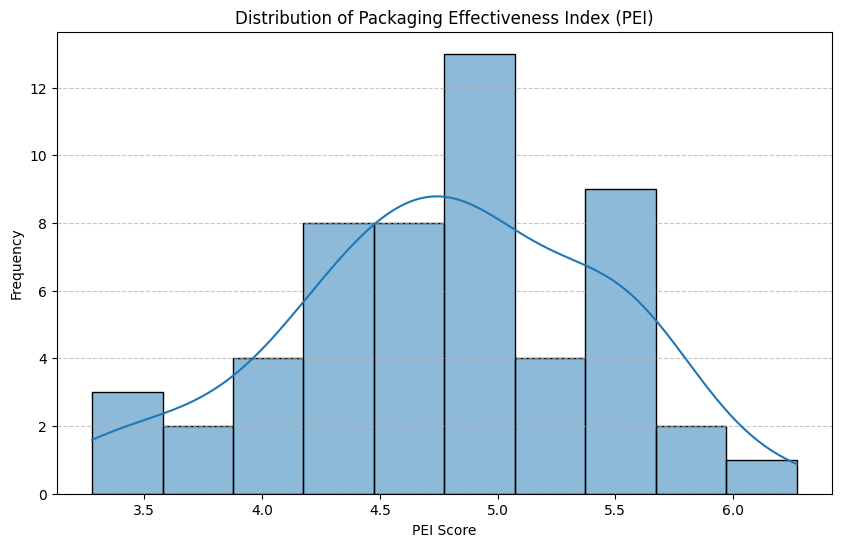

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of PEI scores
plt.figure(figsize=(10, 6))
sns.histplot(final_df['PEI'], kde=True, bins=10)
plt.title('Distribution of Packaging Effectiveness Index (PEI)')
plt.xlabel('PEI Score')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_11246/1006564514.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Brand', y='PEI', data=top_10_pei, palette='viridis')


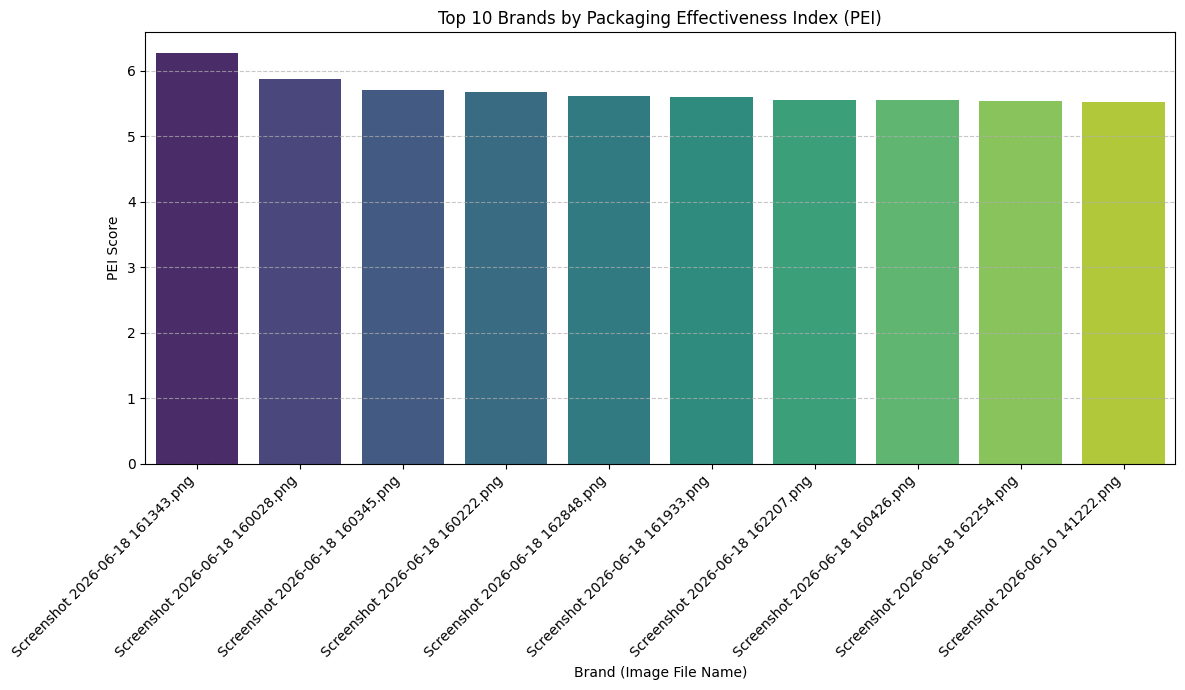

In [ ]:
# Top 10 Brands by PEI
top_10_pei = final_df.sort_values(by='PEI', ascending=False).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x='Brand', y='PEI', data=top_10_pei, palette='viridis')
plt.title('Top 10 Brands by Packaging Effectiveness Index (PEI)')
plt.xlabel('Brand (Image File Name)')
plt.ylabel('PEI Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_11246/3635533169.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Structure', y='PEI', data=avg_pei_by_structure, palette='mako', ax=axes[0])
/tmp/ipykernel_11246/3635533169.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Structure', y='Clarity_Score', data=avg_clarity_by_structure, palette='rocket', ax=axes[1])


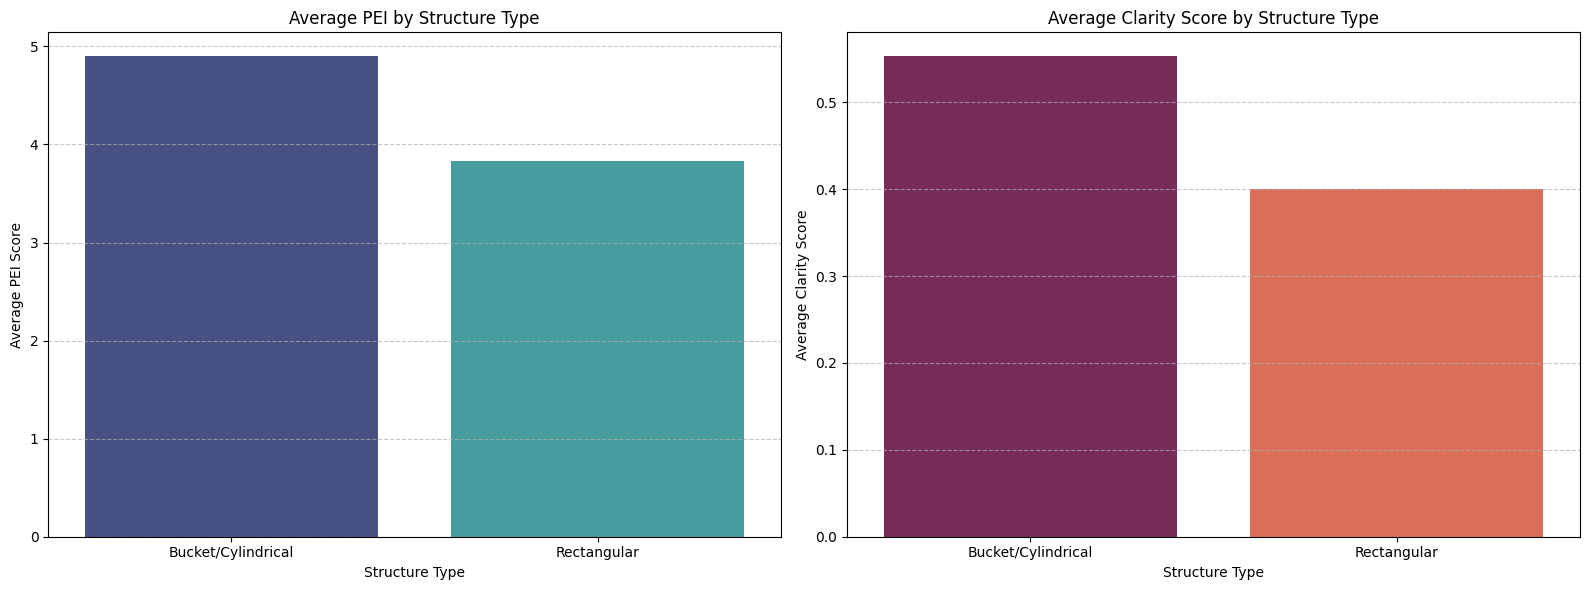

In [ ]:
# Bar plots for Average PEI and Clarity Score by Structure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x='Structure', y='PEI', data=avg_pei_by_structure, palette='mako', ax=axes[0])
axes[0].set_title('Average PEI by Structure Type')
axes[0].set_xlabel('Structure Type')
axes[0].set_ylabel('Average PEI Score')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

sns.barplot(x='Structure', y='Clarity_Score', data=avg_clarity_by_structure, palette='rocket', ax=axes[1])
axes[1].set_title('Average Clarity Score by Structure Type')
axes[1].set_xlabel('Structure Type')
axes[1].set_ylabel('Average Clarity Score')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Summary Statistics for `final_df`

In [ ]:
# Summary statistics for the final DataFrame
display(final_df.describe())

,Brightness,Saturation,Contrast,Color_Diversity,Whitespace,Structure_Score,Text_Count,Benefit_Count,Product_Count,Text_Density,Clarity_Score,Visibility,Premium,Modernity,Hierarchy,PEI
count,54.000000,54.000000,54.000000,54.000000,54.000000,54.000000,54.000000,54.000000,54.000000,54.000000,54.000000,54.000000,54.000000,54.000000,54.000000,54.000000
mean,0.505693,0.477823,0.480187,0.326729,0.392444,0.888889,12.759259,0.592593,1.148148,0.180081,0.535955,4.871296,4.724176,3.990523,8.199191,4.780314
std,0.275400,0.255945,0.224855,0.239687,0.191026,0.317221,7.473059,0.879934,1.122790,0.082124,0.230977,1.342471,1.025846,1.200465,0.821243,0.675439
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.152115,2.422997,1.090902,6.526200,3.278612
25%,0.311431,0.256203,0.315117,0.120812,0.272478,1.000000,7.000000,0.000000,0.000000,0.130203,0.323600,3.839477,4.197792,3.251142,7.712137,4.358077
50%,0.502507,0.487441,0.461203,0.284953,0.386794,1.000000,13.000000,0.000000,1.000000,0.167605,0.472414,4.960571,4.733799,3.907412,8.323951,4.833333
75%,0.721740,0.663605,0.642547,0.458635,0.507595,1.000000,17.000000,1.000000,2.000000,0.228786,0.717085,5.726082,5.301285,4.645660,8.697975,5.356224
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,32.000000,3.000000,3.000000,0.347380,1.000000,7.017880,7.714466,7.333660,10.000000,6.270084
